# Implementacão - Dask

## Detalhes

1. Gestão de Dados
- Dask não herda variáveis globais via Copy-on-Write (fork) da mesma forma transparente que o *multiprocessing*.
- Os daods precisam ser movidos epxlicitamente
- É necessário utilizar *client.scatter* para enviar as matrizes aos workers de forma eficiente.
- Usando client.scatter, os dadossão enviados uma única vez para a memória distribuída do cluster, e os workers acessam essa referência. Isso adiciona um overhead de comunicação que não existia no script original.

2. Scheduler e Workers
- O Dask sobe um Scheduler (agendador) e Workers (trabalhadores).
- Os workers são processos "daemon" de longa duração que ficam aguardando instruções via protocolo TCP (mesmo localmente).
- Eles não "herdam" o estado do script principal da mesma forma simples.
- O Dask serializa (empacota com pickle ou cloudpickle) **a função e os dados** e os envia via rede/socket para o worker.

3. Vantagens de utilizar Dask
- Multi-Node: Dask consegue executar programas utilizando usando múltiplas CPUs (múltiplos nodos) de diferentes computadores da rede. O multiprocessing não faz isso; o Dask faz transparentemente (basta apontar o IP do scheduler).
- Matrizes Gigantes (Out-of-Core): Se MATRIX_SIZE fosse 50.000 e não coubesse na RAM o comando *dask.array* quebraria a matriz em pedaços menores e carregaria do disco sob demanda.

## Dashboard

- O Dask oferece um dashboard web (porta 8787) para visualizar o uso de CPU/Memória em tempo real.
- Dashboard: http://127.0.0.1:8787
- Dependência:

```bash
pip install "bokeh!=3.0.*,>=2.4.2" --proxy "http://proxy.tjrs.gov.br:8080"
```

## Funcinamento do script

1. **O Cluster Dask** (*LocalCluster* e *Client*)

```python
with LocalCluster(n_workers=len(cores), threads_per_worker=1, processes=True...) as cluster:
    with Client(cluster) as client:
```        

- **LocalCluster**: Cria um "mini datacenter" dentro do seu computador.
- **processes=True**: Em Python, threads normais não rodam em paralelo real (devido ao GIL). Ao usar processos, cada worker é um programa Python independente com sua própria memória.
- **threads_per_worker=1**: Reforça que cada worker é puramente single-threaded. Isso é ideal para tarefas CPU-bound (matemática pesada), pois evita a troca de contexto desnecessária.

2. Compartilhamento de dados com *client.scatter*

```python
A_future = client.scatter(A_host, broadcast=True)
B_future = client.scatter(B_host, broadcast=True)
``` 

- Em bibliotecas comuns (multiprocessing), ao enviar dados para um processo filho, o Python precisa "serializar" (pickle) e copiar os dados. Se a matriz possui 1GB e existem 8 workers, são copiados 8GB de dados, saturando a RAM.
- Ao utilziar *scatter* a matriz é enviada para a memória dos workers antes da computação começar (memória compartilhada).
- É retornado um *Future* (uma espécie de "ticket" ou ponteiro).
- Os workers acessam os dados pelo "ticket", sem necessidade de copiar a matriz inteira novamente. Ao utilizar *broadcast=True*, todos os workers já têm uma cópia da matriz B e do pedaço de A prontos em suas memórias locais.

## Versão do Python

- O Python 3.12 deve ser executado para o script Dask.

1. Verificar com *pyenv* as versões

```bash
pyenv versions
```

2. Para instalar o Python 3.12 no *pyenv*. Ao selecionar a versão 3.12, acabou instalado o Python 3.12.12

```bash
pyenv install 3.12
```

3. Versão global: selecionar a versão 3.12.12
- Isto define a versão padrão para todos os shells e diretórios, a menos que uma versão local ou shell a substitua.

```bash
pyenv global 3.12.12
```

4. Nível Shell (Temporário)
- Isto define a versão apenas para a sessão atual do terminal. É temporário e se reverte ao fechar o terminal.


```bash
pyenv shell 3.12.12
```








## Execução do Jupyer Notebook

```python
# -----------------------------------------------------------
# CONFIGURAÇÃO CRÍTICA DE THREADS (BLAS/NUMPY)
# Deve vir ANTES de importar numpy ou dask
# -----------------------------------------------------------
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
# -----------------------------------------------------------
```

### Comando Bash

```bash
OMP_NUM_THREADS=1 MKL_NUM_THREADS=1 VECLIB_MAXIMUM_THREADS=1 OPENBLAS_NUM_THREADS=1 NUMEXPR_NUM_THREADS=1 jupyter notebook
```

- Isso garante que o teste (P-cores vs E-cores) seja cientificamente preciso e que **1 Worker = 1 Núcleo = 1 Thread**. 

- Essa é a maneira **mais segura e robusta** de garantir o comportamento desejado.

- Ao iniciar o Jupyter dessa forma, são definidas as variáveis de ambiente no processo pai (o servidor do Notebook). Por padrão, em sistemas Linux/Unix:
    - O **Jupyter Notebook** herda essas variáveis.
    - O **Kernel do Python** (onde o script executa) é filho do Jupyter e herda dele.
    - Os **Workers do Dask** (*LocalCluster*) são filhos do Kernel e herdam dele.
    - O **NumPy/BLAS** (carregado dentro dos workers) lê as variáveis de ambiente na hora da importação.



In [8]:
import os
import numpy as np

# 1. Verificar se a variável existe no ambiente do Kernel
print(f"OMP_NUM_THREADS: {os.environ.get('OMP_NUM_THREADS')}")
print(f"OPENBLAS_NUM_THREADS: {os.environ.get('OPENBLAS_NUM_THREADS')}")

OMP_NUM_THREADS: 1
OPENBLAS_NUM_THREADS: 1


## Confirmação de versão do Python em uso

In [5]:
import sys
print(sys.version_info)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)


In [2]:
import psutil
import getpass
import os
import sys
import time
import numpy as np
import pandas as pd
from datetime import datetime
from dask.distributed import Client, LocalCluster

# --------------------------------------
# CONFIGURATION
MATRIX_SIZE = 2000
CPU_SETS = {   
    "8P_HT_OFF": [0, 2, 4, 6, 8, 10, 12, 14], # p-cores (8 cores, 1 thread per core)
    "4P_HT_ON": [0, 1, 2, 3, 4, 5, 6, 7], # p-cores (4 cores, 2 threads per core)
    "4P_4E_HT_OFF": [0, 2, 4, 6, 16, 17, 18, 19], # p-cores e e-cores (4 cores p-core, 4 cores e-core)
    "8E": [16, 17, 18, 19, 20, 21, 22, 23] # e-cores (8 cores, 1 thread per core)
}
NUM_RUNS = 5
GOVERNOR = "performance"
IDLE_TIME = 5

# --------------------------------------
# Helper Functions (Governor & Safety)
def safety_check(cpu_ids):
    if MATRIX_SIZE % len(cpu_ids) != 0:
        print(f"Error: MATRIX_SIZE ({MATRIX_SIZE}) not divisible by workers ({len(cpu_ids)}).")
        sys.exit(1)

def set_governor(governor: str):
    """
    Altera o CPU governor de todos os núcleos para o valor especificado.

    Parâmetros:
        governor (str): nome do governor (ex.: "performance", "powersave", "schedutil").
    """
    password = getpass.getpass("Sudo password: ")

    # Interpolamos o valor do parâmetro governor dirTempetamente no comando bash
    bash_command = f"""
    for cpu_file in $(ls -v /sys/devices/system/cpu/cpu*/cpufreq/scaling_governor); do
        cpu_name=$(basename $(dirname $(dirname $cpu_file)))
        
        echo "{governor}" | sudo tee $cpu_file > /dev/null
        
        current_gov=$(cat $cpu_file)
        #echo "$cpu_name: $current_gov"
    done
    """

    # Usa sudo -S para aceitar senha via stdin
    command = f'echo "{password}" | sudo -S bash -c \'{bash_command}\''
    os.system(command)   

def get_governor(cpu_id):
    path = f"/sys/devices/system/cpu/cpu{cpu_id}/cpufreq/scaling_governor"
    try:
        with open(path) as f: return f.read().strip()
    except FileNotFoundError: return "N/A"

# --------------------------------------
# Worker Task Adaptada para Dask
def worker_task_dask(args):
    """
    Recebe os dados explicitamente (A e B são referências scatter do Dask).
    """
    row_index, chunk_size, cpu_ids, A_matrix, B_matrix = args
    
    # Identificação rudimentar do worker baseada no chunk (assumindo ordem)
    # Em Dask, isso é menos determinístico, mas funciona se tasks == workers
    worker_id = row_index // chunk_size 
    target_cpu = cpu_ids[worker_id % len(cpu_ids)]

    # Define afinidade
    p = psutil.Process(os.getpid())
    p.cpu_affinity([target_cpu])
    
    # Fatia a matriz A localmente
    start_row = row_index
    end_row = row_index + chunk_size
    A_chunk = A_matrix[start_row:end_row, :]

    # -------------------------------------------------------------------------
    # LER A AFINIDADE REGISTRADA PELO SISTEMA
    # p.cpu_affinity() sem argumentos retorna a lista de cores restritos
    
    # O Dask worker é um processo, então esperamos que a lista tenha apenas um elemento
    #registered_cores = p.cpu_affinity() 
    
    # Usamos [0] para obter o ID do núcleo
    #system_core = registered_cores[0] if registered_cores else "N/A"
    
    #print(f"Worker PID: {os.getpid()} | Core Definido (target_cpu): {target_cpu} | Core REGISTRADO pelo Sistema: {system_core}")
    # -------------------------------------------------------------------------
    
    # Cálculo
    return np.dot(A_chunk, B_matrix)

# --------------------------------------
# Main Execution
if __name__ == "__main__":
    # print("Passo 1: Configurar governor")
    set_governor(GOVERNOR) # Descomente se tiver permissões sudo

    results = []
    print("Passo 2: Execuções com Dask")

    # Gerar dados
    A_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    B_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    
    for run in range(1, NUM_RUNS + 1):
        for label, cores in CPU_SETS.items():
            safety_check(cores)
            governor = get_governor(cores[0])            

            chunk_size = MATRIX_SIZE // len(cores)

            # -------------------------------------------------------
            # INÍCIO DO BLOCO DASK
            # Criamos um cluster local efêmero para simular o Pool
            # threads_per_worker=1 garante que é multiprocesso puro, não multithread
            # -------------------------------------------------------
            with LocalCluster(n_workers=len(cores), 
                              threads_per_worker=1, 
                              processes=True,
                              silence_logs=40) as cluster:
                
                with Client(cluster) as client:
                    # 1. SCATTER: Enviar dados para a memória comparitlhada dos workers
                    # Isso substitui a herança de memória global do fork()
                    # broadcast=True envia para todos os workers antecipadamente
                    A_future = client.scatter(A_host, broadcast=True)
                    B_future = client.scatter(B_host, broadcast=True)

                    # 2. PREPARAR TASKS
                    # Passamos os futures (A_future, B_future) ao invés dos dados crus
                    tasks_args = []
                    for i in range(len(cores)):
                        args = (i * chunk_size, chunk_size, cores, A_future, B_future)
                        tasks_args.append(args)

                    start_time = time.time()     
                        
                    # 3. SUBMIT & GATHER
                    # map envia as tarefas e retorna futures
                    futures = client.map(worker_task_dask, tasks_args)
                    
                    # gather bloqueia até terminar e traz os resultados
                    C_chunks = client.gather(futures)
                    
                    # 4. COMBINAR
                    C = np.vstack(C_chunks)
                    
                    end_time = time.time()
            # -------------------------------------------------------

            total_time = end_time - start_time
            
            # Validação de resultados
            #C_reference = np.matmul(A_host, B_host)
            #is_match = np.allclose(C, C_reference)
            #validacao_ok = "OK" if is_match else "FAIL"
            #print(f"  -> Validação: {validacao_ok}")
            
            results.append({
                "Run": run, "Scenario": label, "CPUs_used": cores,
                "Governor": governor, "Time_sec": total_time, "Result_shape": C.shape
            })
            print(f"Run {run} | Time: {total_time:.4f}s | {label}: {cores}")
            time.sleep(IDLE_TIME)

    df_results = pd.DataFrame(results)
    print("\nResumo Dask:\n", df_results[["Run", "Scenario", "Time_sec"]].sort_values(by="Scenario"))
    
    # cria dataframe com todos os resultados
    df_results = pd.DataFrame(results)
    pd.set_option('display.width', 1000) # Evita quebra de linha do print do df  
    df_reduced = df_results[["Run", "Scenario", "Governor", "Time_sec"]]
    df_sorted = df_reduced.sort_values(by="Scenario", ascending=False)
    print("\nResumo em DataFrame:\n", df_sorted)
    
    # salvar em CSV
    now = datetime.now()
    data_str = now.strftime("%Y%m%d") # formato aaaammdd
    hora_str = now.strftime("%H%M%S") # formato hhmmss
    filename = (
    f"experimentos02-dask/{data_str}_{hora_str}_matrix{MATRIX_SIZE}_"
        f"numruns{NUM_RUNS}_{GOVERNOR}.csv"
    )
    df_results.to_csv(filename, index=False)
    print(f"\nResultados salvos em: {filename}") 
    
    

Sudo password: ········


[sudo] senha para jgross: 

Passo 2: Execuções com Dask
Run 1 | Time: 1.4230s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 1 | Time: 1.4646s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 1 | Time: 1.4488s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 1 | Time: 1.4226s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 2 | Time: 1.5527s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 2 | Time: 1.4520s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 2 | Time: 1.4410s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 2 | Time: 1.4743s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 3 | Time: 1.6094s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 3 | Time: 1.4656s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 3 | Time: 1.4865s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 3 | Time: 1.5602s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 4 | Time: 1.5069s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 4 | Time: 1.4540s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 4 | Time: 1.4950s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 4 | Time: 1.4646s | 8E: [16, 

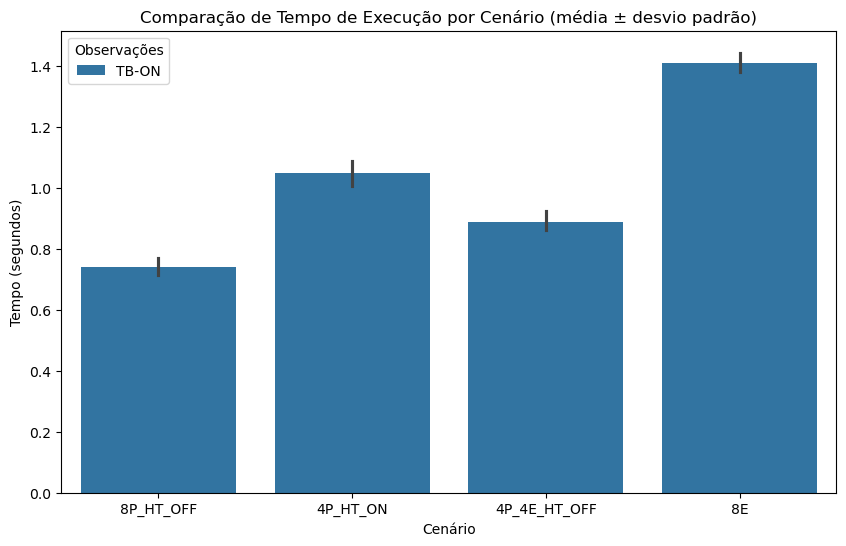

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que seus arquivos estejam em CSV
df1 = pd.read_csv('experimentos03_dask_native_affinity/20251123_194703_matrix2000.csv') # Com Turbo Bost
#df2 = pd.read_csv('20251111_170848_matrix1000_numruns5_performance.csv') 

df1['Dataset'] = 'TB-ON'
#df2['Dataset'] = '-'

#df_combined = pd.concat([df1, df2], ignore_index=True)

plt.figure(figsize=(10,6))
#sns.barplot(x='Scenario', y='Time_sec', hue='Dataset', data=df_combined, ci='sd')
sns.barplot(
    x='Scenario',
    y='Time_sec',
    hue='Dataset',
    data=df1,
    estimator='mean'       # calcula a média automaticamente
    #errorbar='sd'           # mostra desvio padrão
)
plt.title('Comparação de Tempo de Execução por Cenário (média ± desvio padrão)')
plt.ylabel('Tempo (segundos)')
plt.xlabel('Cenário')
plt.legend(title='Observações')

# Salvar como PDF
#plt.savefig('grafico_time_sec.pdf', format='pdf', bbox_inches='tight')

# Salvar como PNG
plt.savefig('grafico_time_sec.png', format='png', dpi=300, bbox_inches='tight')

plt.show()

# Dask - sem afinidade de CPU

- Dask nativo
- Sem afinidade e CPU; o próprio scheduler do Dask aloca as tarefas para cada um dos 8 Workers, sem pré-estabelecer o núcleo de CPU
- Utilziado comando nativo do Dask para muitiplicação de matrizes *da.matmul*

In [1]:
import getpass
import os
import sys
import time
import numpy as np
import pandas as pd
import dask.array as da
from datetime import datetime
from dask.distributed import Client, LocalCluster

# --------------------------------------
# CONFIGURATION
MATRIX_SIZE = 2000
N_WORKERS = 8           # Número fixo de workers solicitado
NUM_RUNS = 5
GOVERNOR = "performance"
IDLE_TIME = 5

# Configuração de Chunks para o Dask Array
# Dividimos a dimensão das linhas pelo número de workers para tentar balancear a carga
CHUNK_SIZE = MATRIX_SIZE // N_WORKERS 

# --------------------------------------
# Helper Functions (Governor)
def set_governor(governor: str):
    """
    Altera o CPU governor de todos os núcleos para o valor especificado.
    """
    try:
        password = getpass.getpass("Sudo password (para governor): ")
        
        # Interpolamos o valor do parâmetro governor diretamente no comando bash
        bash_command = f"""
        for cpu_file in $(ls -v /sys/devices/system/cpu/cpu*/cpufreq/scaling_governor); do
            echo "{governor}" | sudo tee $cpu_file > /dev/null
        done
        """
        command = f'echo "{password}" | sudo -S bash -c \'{bash_command}\''
        os.system(command)
        print(f"Governor definido para: {governor}")
    except Exception as e:
        print(f"Não foi possível definir o governor (talvez falte permissão): {e}")

def get_current_governor():
    # Lê apenas do primeiro núcleo para referência
    path = "/sys/devices/system/cpu/cpu0/cpufreq/scaling_governor"
    try:
        with open(path) as f: return f.read().strip()
    except FileNotFoundError: return "N/A"

# --------------------------------------
# Main Execution
if __name__ == "__main__":
    # 1. Configuração inicial
    # set_governor(GOVERNOR) # Descomente se quiser alterar o governor via script

    results = []
    print(f"Passo 1: Iniciando Dask com {N_WORKERS} workers e Matrizes {MATRIX_SIZE}x{MATRIX_SIZE}")
    print(f"Chunk Size definido: {CHUNK_SIZE} linhas por bloco (aprox)")

    # Criamos o cluster uma única vez ou recriamos a cada run? 
    # Para manter o isolamento similar ao script anterior, vamos criar aqui.
    # threads_per_worker=1 mantém o comportamento de multiprocesso puro.
    with LocalCluster(n_workers=N_WORKERS, 
                      threads_per_worker=1, 
                      processes=True,
                      silence_logs=40) as cluster:
        
        with Client(cluster) as client:
            print(f"Dask Client Dashboard: {client.dashboard_link}")

            # Gerar dados (no Host/Master)
            print("Gerando matrizes aleatórias...")
            A_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
            B_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
            
            for run in range(1, NUM_RUNS + 1):
                current_gov = get_current_governor()
                
                # -------------------------------------------------------
                # DASK NATIVE ARRAY OPERATIONS
                # -------------------------------------------------------

                # 1. Converter Numpy -> Dask Array
                # O parametro 'chunks' define como a matriz é quebrada.
                # (CHUNK_SIZE, MATRIX_SIZE) significa que cortamos em fatias horizontais (linhas)
                # mantendo todas as colunas inteiras, ideal para multiplicação A x B
                dask_A = da.from_array(A_host, chunks=(CHUNK_SIZE, MATRIX_SIZE))
                dask_B = da.from_array(B_host, chunks=(MATRIX_SIZE, CHUNK_SIZE))

                start_time = time.time()
                
                # 2. Definir a operação (Preguiçosa/Lazy)
                # da.matmul é a função nativa de álgebra linear do Dask
                result_lazy = da.matmul(dask_A, dask_B)

                # 3. Executar (Compute)
                # Isso dispara o grafo de tarefas para os 8 workers
                C = result_lazy.compute()

                end_time = time.time()
                # -------------------------------------------------------

                total_time = end_time - start_time
                
                results.append({
                    "Run": run, 
                    "Scenario": f"Dask_Native_{N_WORKERS}Workers", 
                    "Workers": N_WORKERS,
                    "Governor": current_gov, 
                    "Time_sec": total_time, 
                    "Result_shape": C.shape
                })
                
                print(f"Run {run} | Time: {total_time:.4f}s | Workers: {N_WORKERS}")
                
                # Pausa para resfriamento/estabilização
                time.sleep(IDLE_TIME)

    # Consolidação dos resultados
    df_results = pd.DataFrame(results)
    
    # Exibir resumo
    print("\nResumo Dask Nativo:\n", df_results[["Run", "Time_sec"]])
    
    # Salvar CSV
    now = datetime.now()
    data_str = now.strftime("%Y%m%d")
    hora_str = now.strftime("%H%M%S")
    filename = (
        f"experimentos02-dask_native/{data_str}_{hora_str}_matrix{MATRIX_SIZE}_"
        f"numruns{NUM_RUNS}_{GOVERNOR}.csv"
    )
    
    # Garantir que diretório existe
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    df_results.to_csv(filename, index=False)
    print(f"\nResultados salvos em: {filename}")

Passo 1: Iniciando Dask com 8 workers e Matrizes 2000x2000
Chunk Size definido: 250 linhas por bloco (aprox)
Dask Client Dashboard: http://127.0.0.1:8787/status
Gerando matrizes aleatórias...


/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 61.04 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Run 1 | Time: 0.9447s | Workers: 8


/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 61.04 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Run 2 | Time: 0.7739s | Workers: 8


...

Run 3 | Time: 0.7771s | Workers: 8


/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 61.04 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Run 4 | Time: 0.7560s | Workers: 8


/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 61.04 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Run 5 | Time: 0.8298s | Workers: 8

Resumo Dask Nativo:
    Run  Time_sec
0    1  0.944652
1    2  0.773882
2    3  0.777101
3    4  0.755967
4    5  0.829764

Resultados salvos em: experimentos02-dask_native/20251123_192752_matrix2000_numruns5_performance.csv


# Diferenças: Dask com CPU set vs. Dask nativo

- Dask com CPU set:
    - Script elaborado com afinidade de CPu para cada Worker
    - Utiliza *np.dot(A_chunk, B_matrix)* para calcular partes da matriz final e *C = np.vstack(C_chunks)* para agregar os resultados de todos os workers.
    
- Dask nativo:
    - Não seta o núcleo de CPU que cada worker utiliza. Isso fica a cargo do Scheduler do Cluster Dask (transparente)
    - Utiliza *da.matmul* para calcular a multiplicação das duas matrizes. A função faz a distribuição dos dados, computação fracionada em cada worker e agregação dos resultados.

## 1. "Black Box" vs. "White Box" (Otimização do Grafo)
- **Seu script manual** (*client.map*): Para o Dask, a sua função *worker_task_dask* é uma **"caixa preta"**. O Dask não sabe que você está fazendo uma multiplicação de matrizes; ele apenas vê uma função Python genérica. Ele serializa (empacota) essa função, envia para o worker, o worker desempacota, roda o interpretador Python, chama o *psutil*, faz o slice manual e só então chama o NumPy.

- **Dask Nativo** (*da.matmul*): O Dask **sabe** exatamente o que é essa operação. Ele *cria um grafo de tarefas otimizado especificamente para álgebra linear*. Ele evita o overhead de serializar funções Python customizadas pesadas e pula direto para as rotinas otimizadas de baixo nível.


## 2. O Custo das "System Calls" (Overhead do psutil)
No seu script original, cada tarefa executa isto:

```python
p = psutil.Process(os.getpid())
p.cpu_affinity([target_cpu])
```

Essa operação é uma **System Call** (chamada de sistema). O processo Python tem que parar, pedir ao Kernel do Linux para mudar sua afinidade, o Kernel aplica a mudança e devolve o controle. Em uma computação de 1.4 segundos, gastar alguns milissegundos conversando com o Kernel repetidamente em cada worker adiciona uma latência desnecessária. O Dask nativo não perde tempo negociando com o SO; ele apenas calcula.


## 3. Rigidez vs. Flexibilidade do SO
Ao forçar a afinidade (*cpu_affinity*), você está lutando contra o escalonador do Linux:

- **Cenário Manual**: Se você força o Worker 1 a usar o Core 0, mas o Core 0 de repente precisa processar uma interrupção de rede ou uma tarefa do sistema, o Worker 1 fica **parado** esperando o Core 0 liberar.

- **Cenário Nativo**: O Dask deixa o Sistema Operacional decidir. Se o Core 0 estiver ocupado, o Linux move o processo instantaneamente para o Core 1 (que pode estar ocioso). Essa fluidez mantém a CPU em 100% de uso efetivo muito mais tempo.


## 4. Gestão de Memória e Slicing
- **Manual**: Você passa *row_index* e *chunk_size* e faz o slice *A_chunk = A_matrix\[start:end\]* dentro do tempo de execução da tarefa. Isso envolve operações Python para calcular índices e criar visualizações de memória.

- **Nativo**: O *dask.array* já possui a estrutura de blocos ("chunks") pré-calculada nos metadados. Quando a tarefa chega ao processador, o ponteiro de memória correto já está pronto para ser entregue ao BLAS (biblioteca matemática de C/Fortran), com quase zero interferência do Python.


## Resultado

O script Dask nativo é mais rápido porque **remove o "middleware" Python**.

Ele passa menos tempo gerenciando onde rodar e como cortar os dados, e mais tempo deixando as bibliotecas de C/C++ (que o NumPy/Dask usam internamente) fazerem a matemática pura.

# 3º Script: Dask compute com pool de núcleos

- Script usa a velocidade do *da.matmul* nativo, mas restringe o Cluster inteiro a rodar apenas nos E-cores ou apenas nos P-cores (sem setar afinidade por worker individual, mas sim pelo processo pai)

- O isolamento rigoroso de hardware (P-cores vs E-cores) é aplicado com o conceito de **Herança de Afinidade de Processo**.
    - Isolamento Real: Ao definir a afinidade no processo **pai** antes do *fork*, o Kernel do Linux garante que nenhum worker escape dos núcleos designados. Um worker tentando usar 100% de CPU não vai "vazar" para um E-core se você definiu apenas P-cores.


## A Lógica da Solução
Em sistemas Linux, quando um processo pai cria um processo filho (que é o que o *LocalCluster* faz ao criar workers), o filho **herda** a máscara de afinidade de CPU do pai.

1. **Antes** de iniciar o Cluster, o script principal define sua própria afinidade (ex: "Só posso usar os núcleos 16 a 23").

2. O script inicia o *LocalCluster*.

3. O Cluster lança 8 workers. Como o pai está restrito a um conjunto de núcleos, o sistema operacional obriga os 8 workers a nascerem e viverem apenas nesses núcleos.

4. **Resultado**: Você tem controle total do hardware sem precisar colocar código *psutil* lento dentro do loop de cálculo do Dask.


## Informações importantes

Tecnicamente, ao definir *processes=True* e *threads_per_worker=1*:

1. **Dask Scheduler**: O Dask entende que cada worker só consegue lidar com **uma tarefa Python** por vez.

2. **Python**: Haverá 8 processos Python independentes rodando no SO.

3. **Concorrência**: O Dask não tentará fazer duas coisas ao mesmo tempo dentro do mesmo worker.

# 3º Script: Dask compute com pool de núcleos - Sem leitura de arquivo

In [9]:
import getpass
import os
import sys
import time
import psutil
import numpy as np
import pandas as pd
import dask.array as da
from datetime import datetime
from dask.distributed import Client, LocalCluster

# --------------------------------------
# CONFIGURATION
MATRIX_SIZE = 6000
CPU_SETS = {    
    "8P_HT_OFF": [0, 2, 4, 6, 8, 10, 12, 14], 
    "4P_HT_ON": [0, 1, 2, 3, 4, 5, 6, 7], 
    "4P_4E_HT_OFF": [0, 2, 4, 6, 16, 17, 18, 19], 
    "8E": [16, 17, 18, 19, 20, 21, 22, 23] 
}
NUM_RUNS = 5
GOVERNOR = "performance"
IDLE_TIME = 5
N_WORKERS = 8 # Mantendo fixo conforme solicitado

# --------------------------------------
# Helper Functions
def get_worker_info():
    """
    Esta função roda dentro de cada worker.
    Retorna o PID e o Núcleo (Core) que está sendo usado naquele instante.
    """
    import psutil
    import os
    p = psutil.Process(os.getpid())
    
    return {
        "pid": os.getpid(),
        # cpu_num() retorna o ID do núcleo físico/lógico onde o processo está rodando AGORA
        "core": p.cpu_num(), 
        # cpu_affinity() retorna a lista de núcleos PERMITIDOS para este worker
        "affinity": p.cpu_affinity() 
    }

def set_governor(governor: str):
    try:
        password = getpass.getpass("Sudo password (para governor): ")
        bash_command = f"""
        for cpu_file in $(ls -v /sys/devices/system/cpu/cpu*/cpufreq/scaling_governor); do
            echo "{governor}" | sudo tee $cpu_file > /dev/null
        done
        """
        command = f'echo "{password}" | sudo -S bash -c \'{bash_command}\''
        os.system(command)
        print(f"Governor definido para: {governor}")
    except Exception as e:
        print(f"Erro ao definir governor: {e}")

def get_current_governor(cpu_id=0):
    path = f"/sys/devices/system/cpu/cpu{cpu_id}/cpufreq/scaling_governor"
    try:
        with open(path) as f: return f.read().strip()
    except FileNotFoundError: return "N/A"

# --------------------------------------
# Main Execution
if __name__ == "__main__":
    # set_governor(GOVERNOR) # Descomente para ativar

    # Gerar dados uma única vez na memória principal
    print("Gerando matrizes no Host...")
    A_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    B_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)

    results = []

    # Loop pelos Cenários de CPU (P-cores, E-cores, etc)
    for label, cores in CPU_SETS.items():
        print(f"\n--- Iniciando Cenário: {label} ---")
        print(f"Restringindo processo Pai aos núcleos: {cores}")
        
        # 1. MÁGICA AQUI: Restringir o Processo Pai (Script Python atual)
        # Todos os processos filhos (Dask Workers) criados a seguir herdarão essa restrição.
        parent = psutil.Process(os.getpid())
        parent.cpu_affinity(cores)
        
        # Verificação de segurança
        chunk_size = MATRIX_SIZE // N_WORKERS
        
        # 2. Iniciar Cluster (Os workers nascerão "presos" aos núcleos definidos acima)
        # Recriamos o cluster a cada cenário para garantir que a nova afinidade seja aplicada
        with LocalCluster(n_workers=N_WORKERS, 
                          threads_per_worker=1, 
                          processes=True, # Obrigatório para herança de afinidade funcionar bem aqui
                          silence_logs=40) as cluster:
            
            with Client(cluster) as client:
                # Aquecimento opcional ou apenas info
                # print(f"Client pronto: {client.dashboard_link}")
                
                # --- SONDA: VERIFICAR ONDE OS WORKERS ESTÃO ---
                # client.run executa a função em TODOS os workers e retorna um dicionário
                workers_info = client.run(get_worker_info)
                
                print("\n[Status dos Workers]")
                for worker_addr, info in workers_info.items():
                    # Extraímos o IP/Porta ou apenas usamos um contador se preferir
                    print(f" -> Worker PID {info['pid']} | Core Atual: {info['core']:>2} | Afinidade: {info['affinity']}")
                print("-" * 60)
                # ----------------------------------------------
                
                for run in range(1, NUM_RUNS + 1):
                    # Coleta governor do primeiro núcleo do set atual para registro
                    gov_actual = get_current_governor(cores[0])
                    
                    start_time = time.time()

                    # ---------------------------------------------------
                    # OPERAÇÃO NATIVA DO DASK
                    # ---------------------------------------------------
                    
                    # Criação dos arrays distribuídos (Lazy)
                    # chunks=(CHUNK_SIZE, MATRIX_SIZE) -> divide em fatias horizontais
                    dask_A = da.from_array(A_host, chunks=(chunk_size, MATRIX_SIZE))
                    dask_B = da.from_array(B_host, chunks=(MATRIX_SIZE, chunk_size)) 
                    
                    # Multiplicação
                    result_lazy = da.matmul(dask_A, dask_B)
                    
                    # Computação (Dispara para os workers restritos)
                    C = result_lazy.compute()
                    
                    # ---------------------------------------------------
                    
                    end_time = time.time()
                    total_time = end_time - start_time
                    
                    print(f"Run {run} | {label} | Time: {total_time:.4f}s")
                    
                    results.append({
                        "Run": run,
                        "Scenario": label,
                        "CPUs_used": str(cores),
                        "Governor": gov_actual,
                        "Time_sec": total_time,
                        "Result_shape": C.shape
                    })
                    
                    time.sleep(IDLE_TIME)

    # Restaurar afinidade para todos os cores no final (opcional, boa prática)
    all_cores = list(range(psutil.cpu_count()))
    parent.cpu_affinity(all_cores)
    print("\nRestaurada afinidade para todos os núcleos.")

    # Salvar Resultados
    df_results = pd.DataFrame(results)
    print("\nResumo Final:\n", df_results.groupby("Scenario")["Time_sec"].mean())
    
    now = datetime.now()
    filename = f"experimentos03_dask_native_affinity/{now.strftime('%Y%m%d_%H%M%S')}_matrix{MATRIX_SIZE}.csv"
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    df_results.to_csv(filename, index=False)
    print(f"Salvo em: {filename}")

Gerando matrizes no Host...

--- Iniciando Cenário: 8P_HT_OFF ---
Restringindo processo Pai aos núcleos: [0, 2, 4, 6, 8, 10, 12, 14]

[Status dos Workers]
 -> Worker PID 288589 | Core Atual:  0 | Afinidade: [0, 2, 4, 6, 8, 10, 12, 14]
 -> Worker PID 288597 | Core Atual:  8 | Afinidade: [0, 2, 4, 6, 8, 10, 12, 14]
 -> Worker PID 288609 | Core Atual: 10 | Afinidade: [0, 2, 4, 6, 8, 10, 12, 14]
 -> Worker PID 288610 | Core Atual: 12 | Afinidade: [0, 2, 4, 6, 8, 10, 12, 14]
 -> Worker PID 288585 | Core Atual: 14 | Afinidade: [0, 2, 4, 6, 8, 10, 12, 14]
 -> Worker PID 288590 | Core Atual:  2 | Afinidade: [0, 2, 4, 6, 8, 10, 12, 14]
 -> Worker PID 288605 | Core Atual:  0 | Afinidade: [0, 2, 4, 6, 8, 10, 12, 14]
 -> Worker PID 288598 | Core Atual:  8 | Afinidade: [0, 2, 4, 6, 8, 10, 12, 14]
------------------------------------------------------------


/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 549.32 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Run 1 | 8P_HT_OFF | Time: 40.3896s


/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 549.32 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Run 2 | 8P_HT_OFF | Time: 42.3477s


...

Run 3 | 8E | Time: 64.6205s


/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 549.32 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Run 4 | 8E | Time: 64.0809s


/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 549.32 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Run 5 | 8E | Time: 64.2562s

Restaurada afinidade para todos os núcleos.

Resumo Final:
 Scenario
4P_4E_HT_OFF    48.681477
4P_HT_ON        44.080172
8E              64.614592
8P_HT_OFF       47.723856
Name: Time_sec, dtype: float64
Salvo em: experimentos03_dask_native_affinity/20251123_203215_matrix6000.csv


# 3º Script: Dask compute com pool de núcleos - Com leitura de arquivo

```bash
pyenv global 3.12.12
pyenv shell 3.12.12

OMP_NUM_THREADS=1 MKL_NUM_THREADS=1 VECLIB_MAXIMUM_THREADS=1 OPENBLAS_NUM_THREADS=1 NUMEXPR_NUM_THREADS=1 jupyter notebook
```

In [ ]:
import getpass
import os
import sys
import time
import psutil
import numpy as np
import pandas as pd
import dask.array as da
from datetime import datetime
from dask.distributed import Client, LocalCluster
import gc

# --------------------------------------
# CONFIGURATION GLOBAL
PLAN_FILE = "experiments_plan.csv"
GOVERNOR = "performance"
IDLE_TIME = 10  # Tempo de resfriamento entre experimentos

print(sys.version_info)

# --------------------------------------
# Helper Functions
def get_worker_info():
    """
    Esta função roda dentro de cada worker.
    Retorna o PID e o Núcleo (Core) que está sendo usado naquele instante.
    """
    import psutil
    import os
    p = psutil.Process(os.getpid())
    
    return {
        "pid": os.getpid(),
        # cpu_num() retorna o ID do núcleo físico/lógico onde o processo está rodando AGORA
        "core": p.cpu_num(), 
        # cpu_affinity() retorna a lista de núcleos PERMITIDOS para este worker
        "affinity": p.cpu_affinity() 
    }

def set_governor(governor: str):
    try:
        password = getpass.getpass("Sudo password (para governor): ")
        bash_command = f"""
        for cpu_file in $(ls -v /sys/devices/system/cpu/cpu*/cpufreq/scaling_governor); do
            echo "{governor}" | sudo tee $cpu_file > /dev/null
        done
        """
        command = f'echo "{password}" | sudo -S bash -c \'{bash_command}\''
        os.system(command)
        print(f"Governor definido para: {governor}")
    except Exception as e:
        print(f"Erro ao definir governor: {e}")

def get_governor(cpu_id=0):
    path = f"/sys/devices/system/cpu/cpu{cpu_id}/cpufreq/scaling_governor"
    try:
        with open(path) as f: return f.read().strip()
    except FileNotFoundError: return "N/A"

def parse_cpu_list_string(cpu_str):
    """
    Converte string "[0; 2; 4]" para lista [0, 2, 4]
    """
    clean_str = cpu_str.replace('[', '').replace(']', '').replace(' ', '')
    if not clean_str:
        return []
    return [int(x) for x in clean_str.split(';')]

# --------------------------------------
# Main Execution
if __name__ == "__main__":
    # 1. Configuração Inicial
    set_governor(GOVERNOR)

    # 2. Carregar Plano de Experimentos
    if not os.path.exists(PLAN_FILE):
        print(f"Erro: Arquivo '{PLAN_FILE}' não encontrado.")
        sys.exit(1)
    
    df_plan = pd.read_csv(PLAN_FILE)
    print(f"Carregado plano com {len(df_plan)} experimentos.")
    
    # 3. Preparar arquivo de saída
    now = datetime.now()
    timestamp_str = now.strftime("%Y%m%d_%H%M%S")
    output_filename = f"exp02-dask-pool/result_exp_multiprocessing_{timestamp_str}.csv"
    
    print(f"Resultados salvos incrementalmente em: {output_filename}")

    # 4. Loop de Execução
    for idx, row in df_plan.iterrows():
        print(f"Linha {idx}: ", end="", flush=True)
        
        # Extrair dados da linha
        exp_id = row['Experiment_ID']
        matrix_size = int(row['Matrix_Size'])
        cpu_set_name = row['CPU_Set_Name']
        run_number = row['Run_Number']
    
        # Parse da lista de cores
        try:
            cores = parse_cpu_list_string(row['CPU_Cores_List'])
        except Exception as e:
            print(f"Erro ao ler lista de CPUs na linha {idx}: {e}")
            continue
    
        if len(cores) == 0:
            print("Lista de CPUs vazia. Pulando.")
            continue
    
        # Validação de segurança
        if matrix_size % len(cores) != 0:
            print(f"AVISO: Matrix size {matrix_size} não é divisível por {len(cores)} cores.")
            sys.exit(0)
    
        # Gerar Matrizes (Dinâmico tamanho muda)
        # Dados na memória principal
        # Inicializa as matrizes globais
        print(f"Gerando matrizes {matrix_size}x{matrix_size}...", end="", flush=True)       
        A_host = np.random.rand(matrix_size, matrix_size).astype(np.float64)
        B_host = np.random.rand(matrix_size, matrix_size).astype(np.float64)
          
        # Garantir que o governor está correto
        current_governor = get_governor(cores[0])
    
        #print(f"Restringindo processo Pai aos núcleos: {cores}")
        
        # 5. MÁGICA AQUI: Restringir o Processo Pai (Script Python atual)
        # Todos os processos filhos (Dask Workers) criados a seguir herdarão essa restrição.
        parent = psutil.Process(os.getpid())
        parent.cpu_affinity(cores)
        
        # Verificação de segurança
        chunk_size = matrix_size // len(cores)
        
        # 6. Iniciar Cluster (Os workers nascerão "presos" aos núcleos definidos acima)
        # Recriamos o cluster a cada cenário para garantir que a nova afinidade seja aplicada
        with LocalCluster(n_workers=len(cores), 
                          threads_per_worker=1, 
                          processes=True, # Obrigatório para herança de afinidade funcionar bem aqui
                          silence_logs=40) as cluster:
            
            with Client(cluster) as client:
                # Aquecimento opcional ou apenas info
                # print(f"Client pronto: {client.dashboard_link}")
                
                # --- SONDA: VERIFICAR ONDE OS WORKERS ESTÃO ---
                # client.run executa a função em TODOS os workers e retorna um dicionário
                #workers_info = client.run(get_worker_info)
                
                #print("\n[Status dos Workers]")
                #for worker_addr, info in workers_info.items():
                    # Extraímos o IP/Porta ou apenas usamos um contador se preferir
                #    print(f" -> Worker PID {info['pid']} | Core Atual: {info['core']:>2} | Afinidade: {info['affinity']}")
                #print("-" * 60)
                # ----------------------------------------------

                # ---------------------------------------------------
                # OPERAÇÃO NATIVA DO DASK
                # ---------------------------------------------------
                
                # Criação dos arrays distribuídos (Lazy)
                # chunks=(CHUNK_SIZE, MATRIX_SIZE) -> divide em fatias horizontais
                dask_A = da.from_array(A_host, chunks=(chunk_size, matrix_size))
                dask_B = da.from_array(B_host, chunks=(matrix_size, chunk_size)) 

                start_time = time.time()
                
                # Multiplicação
                result_lazy = da.matmul(dask_A, dask_B)

                # Computação (Dispara para os workers restritos)
                C = result_lazy.compute()

                # ---------------------------------------------------

                end_time = time.time()
                total_time = end_time - start_time

                print(f"Fim:{exp_id}|Size:{matrix_size}|Time:{total_time:.4f}s...", end="", flush=True)

                # 5. Salvar Resultado (Append)
                # Copiamos a linha original e adicionamos as métricas
                result_row = row.to_dict()
                result_row['Experiment_ID'] = exp_id
                result_row['Matrix_Size'] = matrix_size
                result_row['CPU_Set_Name'] = cpu_set_name
                result_row['Run_Number'] = run_number
                result_row['Executed_Governor'] = current_governor
                result_row['Time_sec'] = total_time
                result_row['Timestamp'] = datetime.now().isoformat()

                df_result_row = pd.DataFrame([result_row])

                # Se o arquivo não existe, escreve header. Se existe, append sem header.
                header_mode = not os.path.exists(output_filename)
                df_result_row.to_csv(output_filename, mode='a', header=header_mode, index=False)

                # Limpeza agressiva
                A_global = None
                B_global = None
                dask_A = None
                dask_B = None
                del result_lazy
                del C
                gc.collect() # Força limpeza das variáveis

                # Resfriamento
                print(f"{IDLE_TIME}s para estabilização.")
                time.sleep(IDLE_TIME)

    print("\nTodos os experimentos do plano foram concluídos.")

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
Sudo password (para governor): ········
Governor definido para: performance
Carregado plano com 483 experimentos.
Resultados salvos incrementalmente em: exp02-dask-pool/result_exp_multiprocessing_20251125_070422.csv
Linha 0: Gerando matrizes 4000x4000...

[sudo] senha para jgross: /usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 244.15 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Fim:EXP_WARMUP|Size:4000|Time:10.8484s...10s para estabilização.
Linha 1: Gerando matrizes 4000x4000...

/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 244.15 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Fim:EXP_WARMUP|Size:4000|Time:12.1700s...10s para estabilização.
Linha 2: Gerando matrizes 4000x4000...

...

/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 15.27 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Fim:EXP_0074|Size:1000|Time:0.2841s...10s para estabilização.
Linha 4: Gerando matrizes 6000x6000...

/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 549.32 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Fim:EXP_0415|Size:6000|Time:42.9856s...10s para estabilização.
Linha 5: Gerando matrizes 6000x6000...

/usr/lib/python3/dist-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 549.32 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
